#**📘 Physics-Informed Neural Networks (PINNs)**

## **Solving the 1D Transient Heat Equation**

###**📌 Overview**

This notebook demonstrates how a **Physics-Informed Neural Network (PINN)** can be used to solve the **1D transient heat diffusion equation**.

Unlike traditional numerical solvers (FDM, FVM, CFD), PINNs embed the governing **partial differential equation (PDE)** directly into the training process of a neural network, producing **physically consistent solutions** even with sparse data.

The results are validated against an **analytical solution**.

##**🔧 Setup & Imports**

Device: cpu


Training PINN: 100%|██████████| 2000/2000 [04:32<00:00,  7.34it/s, loss=6.48e-04]


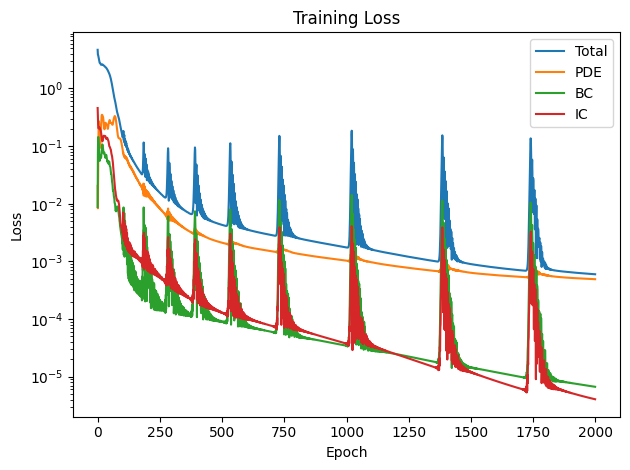

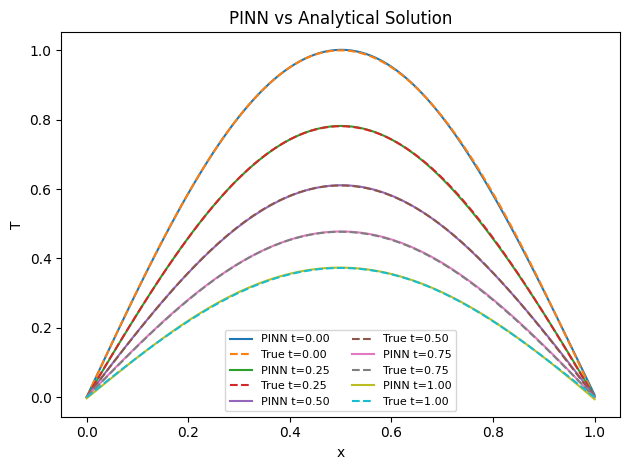

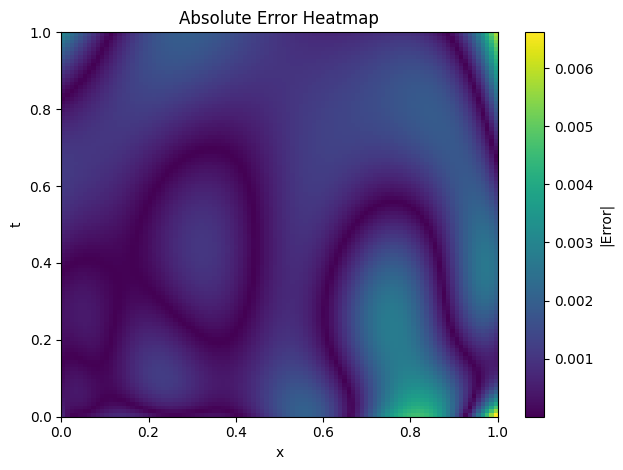

Training complete.
{'rmse': 0.0012038738837566237, 'max_abs_error': 0.006615402642637369, 'epochs': 2000}


In [9]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import trange
import sys

# ----------------------------
# Basic MLP
# ----------------------------
class MLP(nn.Module):
    def __init__(
        self,
        in_dim=2,
        out_dim=1,
        hidden=64,
        depth=5,
        activation=nn.Tanh,
    ):
        super().__init__()

        layers = [nn.Linear(in_dim, hidden), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), activation()]
        layers += [nn.Linear(hidden, out_dim)]

        self.net = nn.Sequential(*layers)

        # Xavier initialization (important for PINNs)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# ----------------------------
# Heat Equation PINN
# ----------------------------
class HeatPINN(nn.Module):
    """
    PINN for 1D heat equation:
        T_t = alpha * T_xx
    """

    def __init__(
        self,
        alpha: float,
        hidden=64,
        depth=5,
        device=None,
        dtype=torch.float32,
    ):
        super().__init__()

        self.alpha = float(alpha)
        self.device = device or (
            "cuda" if torch.cuda.is_available() else "cpu"
        )
        self.dtype = dtype

        self.model = MLP(
            in_dim=2,
            out_dim=1,
            hidden=hidden,
            depth=depth,
            activation=nn.Tanh,
        ).to(self.device, self.dtype)

    # Temperature prediction
    def temperature(self, x, t):
        """
        x, t : tensors of shape (N, 1)
        """
        xt = torch.cat([x, t], dim=1)
        return self.model(xt)

    # PDE residual
    def pde_residual(self, x, t):
        """
        Residual r(x,t) = T_t - alpha * T_xx
        """

        # Ensure correct device, dtype, and grad tracking
        x = x.clone().detach().to(self.device, self.dtype).requires_grad_(True)
        t = t.clone().detach().to(self.device, self.dtype).requires_grad_(True)

        T = self.temperature(x, t)

        # First derivatives
        T_t = torch.autograd.grad(
            T,
            t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
        )[0]

        T_x = torch.autograd.grad(
            T,
            x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
        )[0]

        # Second derivative
        T_xx = torch.autograd.grad(
            T_x,
            x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
        )[0]

        return T_t - self.alpha * T_xx

from utils import set_seed, analytical_solution_sin, make_grid, to_tensor

# ----------------------------
# Sampling helpers
# ----------------------------
def sample_collocation(n_f, L, T_end, device):
    x = np.random.rand(n_f, 1) * L
    t = np.random.rand(n_f, 1) * T_end
    return to_tensor(x, device), to_tensor(t, device)

def sample_boundary(n_b, L, T_end, device):
    t = np.random.rand(n_b, 1) * T_end
    x0 = np.zeros((n_b, 1))
    xL = np.ones((n_b, 1)) * L
    return (
        to_tensor(x0, device), to_tensor(t, device),
        to_tensor(xL, device), to_tensor(t.copy(), device)
    )

def sample_initial(n_i, L, device):
    x = np.random.rand(n_i, 1) * L
    t0 = np.zeros((n_i, 1))
    return to_tensor(x, device), to_tensor(t0, device)

# ----------------------------
# Training
# ----------------------------
def main():
    set_seed(42)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    # Physics
    L = 1.0
    T_end = 1.0
    alpha = 0.1

    # 🔥 Colab-safe sizes
    n_f = 5000
    n_b = 500
    n_i = 500

    epochs = 2000
    lr = 1e-3

    w_pde, w_bc, w_ic = 1.0, 10.0, 10.0

    pinn = HeatPINN(alpha=alpha, hidden=64, depth=5, device=device)
    optimizer = torch.optim.Adam(pinn.parameters(), lr=lr)

    # Training points
    x_f, t_f = sample_collocation(n_f, L, T_end, device)
    x0, tb, xL, tb2 = sample_boundary(n_b, L, T_end, device)
    x_i, t_i = sample_initial(n_i, L, device)

    T_bc0 = torch.zeros_like(tb)
    T_bcL = torch.zeros_like(tb2)
    T_ic = torch.sin(np.pi * x_i)

    history = {"loss": [], "pde": [], "bc": [], "ic": []}

    pbar = trange(epochs, desc="Training PINN")
    for ep in pbar:
        optimizer.zero_grad()

        r = pinn.pde_residual(x_f, t_f)
        loss_pde = torch.mean(r**2)

        T0 = pinn.temperature(x0, tb)
        TL = pinn.temperature(xL, tb2)
        loss_bc = torch.mean((T0 - T_bc0)**2) + torch.mean((TL - T_bcL)**2)

        Ti = pinn.temperature(x_i, t_i)
        loss_ic = torch.mean((Ti - T_ic)**2)

        loss = w_pde*loss_pde + w_bc*loss_bc + w_ic*loss_ic
        loss.backward()
        optimizer.step()

        history["loss"].append(loss.item())
        history["pde"].append(loss_pde.item())
        history["bc"].append(loss_bc.item())
        history["ic"].append(loss_ic.item())

        if ep % 100 == 0:
            pbar.set_postfix(loss=f"{loss.item():.2e}")

    # ----------------------------
    # Evaluation
    # ----------------------------
    results_dir = "results"
    os.makedirs(results_dir, exist_ok=True)

    n_x, n_t = 101, 101
    xs, ts, X, TT = make_grid(n_x, n_t, L, T_end)
    XT = np.stack([X.flatten(), TT.flatten()], axis=1)

    with torch.no_grad():
        xt = torch.tensor(XT, dtype=torch.float32, device=device)
        pred = pinn.model(xt).cpu().numpy().reshape(n_t, n_x)

    true = analytical_solution_sin(alpha, X, TT)
    err = np.abs(pred - true)

    # ----------------------------
    # Visuals (INLINE for Colab)
    # ----------------------------
    plt.figure()
    plt.plot(history["loss"], label="Total")
    plt.plot(history["pde"], label="PDE")
    plt.plot(history["bc"], label="BC")
    plt.plot(history["ic"], label="IC")
    plt.yscale("log")
    plt.legend()
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.savefig(f"{results_dir}/loss_curves.png", dpi=200)
    plt.show()

    plt.figure()
    for t_pick in [0.0, 0.25, 0.5, 0.75, 1.0]:
        idx = int(t_pick * (n_t - 1))
        plt.plot(xs, pred[idx], label=f"PINN t={t_pick:.2f}")
        plt.plot(xs, true[idx], "--", label=f"True t={t_pick:.2f}")
    plt.legend(ncol=2, fontsize=8)
    plt.title("PINN vs Analytical Solution")
    plt.xlabel("x")
    plt.ylabel("T")
    plt.tight_layout()
    plt.savefig(f"{results_dir}/time_slices.png", dpi=200)
    plt.show()

    plt.figure()
    plt.imshow(err, origin="lower", aspect="auto",
               extent=[0, L, 0, T_end])
    plt.colorbar(label="|Error|")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("Absolute Error Heatmap")
    plt.tight_layout()
    plt.savefig(f"{results_dir}/error_heatmap.png", dpi=200)
    plt.show()

    metrics = {
        "rmse": float(np.sqrt(np.mean((pred - true) ** 2))),
        "max_abs_error": float(np.max(err)),
        "epochs": epochs
    }

    with open(f"{results_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print("Training complete.")
    print(metrics)

if __name__ == "__main__":
    main()

##**Code break down and explanation**

In [11]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import trange

plt.style.use("seaborn-v0_8")

##**⚙️ Reproducibility & Compute Device**

In [12]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


##**🧠 Neural Network Architecture**

We use a fully-connected **Multi-Layer Perceptron (MLP)** with:
- Tanh activations
- Xavier weight initialization
- Inputs: spatial coordinate `x` and time `t`
- Output: temperature `T(x,t)`

##**🔌 MLP Definition**

In [13]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden=64, depth=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

##**🔥 Physics-Informed Neural Network**

## Physics-Informed Neural Network (PINN)

We enforce the **heat equation**:

∂T/∂t = α · ∂²T/∂x²

using automatic differentiation.

##**🧠 HeatPINN Class**

In [14]:
class HeatPINN(nn.Module):
    def __init__(self, alpha, hidden=64, depth=5):
        super().__init__()
        self.alpha = alpha
        self.model = MLP(hidden=hidden, depth=depth).to(device)

    def temperature(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.model(xt)

    def pde_residual(self, x, t):
        x = x.clone().detach().to(device).requires_grad_(True)
        t = t.clone().detach().to(device).requires_grad_(True)

        T = self.temperature(x, t)

        T_t = torch.autograd.grad(T, t, torch.ones_like(T), create_graph=True)[0]
        T_x = torch.autograd.grad(T, x, torch.ones_like(T), create_graph=True)[0]
        T_xx = torch.autograd.grad(T_x, x, torch.ones_like(T_x), create_graph=True)[0]

        return T_t - self.alpha * T_xx

##**📐 Problem Definition**

## Problem Definition

Domain:
- x ∈ [0, 1]
- t ∈ [0, 1]

Boundary conditions:
- T(0,t) = 0
- T(1,t) = 0

Initial condition:
- T(x,0) = sin(πx)

Analytical solution:
- T(x,t) = exp(-απ²t) sin(πx)

##**📊 Sampling Functions**

In [15]:
def sample_collocation(n, L, T_end):
    x = torch.rand(n, 1, device=device)
    t = torch.rand(n, 1, device=device)
    return x * L, t * T_end

def sample_boundary(n, L, T_end):
    t = torch.rand(n, 1, device=device) * T_end
    return torch.zeros_like(t), t, torch.ones_like(t)*L, t

def sample_initial(n, L):
    x = torch.rand(n, 1, device=device) * L
    return x, torch.zeros_like(x)

##**🚀 Training the PINN**

The loss function combines:
- PDE residual loss
- Boundary condition loss
- Initial condition loss

##**🏋️ Training Loop**

**Training Loss Convergence**

The plot below shows stable convergence of:
- PDE loss
- Boundary condition loss
- Initial condition loss

In [18]:
# ----------------------------
# Training the PINN
# ----------------------------

alpha = 0.1
pinn = HeatPINN(alpha=alpha).to(device)
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)

epochs = 2000

# Loss weights
w_pde = 1.0
w_bc  = 10.0
w_ic  = 10.0

history = {
    "loss": [],
    "pde": [],
    "bc": [],
    "ic": []
}

# Domain parameters
L = 1.0
T_end = 1.0

# Sampling sizes (Colab-safe)
n_f = 5000
n_b = 500
n_i = 500

# Fixed training points
x_f, t_f = sample_collocation(n_f, L, T_end)
x0, tb, xL, tb2 = sample_boundary(n_b, L, T_end)
x_i, t_i = sample_initial(n_i, L)

# Targets
T_bc0 = torch.zeros_like(tb)
T_bcL = torch.zeros_like(tb2)
T_ic  = torch.sin(np.pi * x_i)

pbar = trange(epochs, desc="Training PINN")

for epoch in pbar:
    optimizer.zero_grad()

    # PDE residual loss
    r = pinn.pde_residual(x_f, t_f)
    loss_pde = torch.mean(r**2)

    # Boundary condition loss
    T_left  = pinn.temperature(x0, tb)
    T_right = pinn.temperature(xL, tb2)
    loss_bc = torch.mean((T_left - T_bc0)**2) + \
              torch.mean((T_right - T_bcL)**2)

    # Initial condition loss
    T_init = pinn.temperature(x_i, t_i)
    loss_ic = torch.mean((T_init - T_ic)**2)

    # Total loss
    loss = (
        w_pde * loss_pde +
        w_bc  * loss_bc +
        w_ic  * loss_ic
    )

    # Backpropagation
    loss.backward()
    optimizer.step()

    # Logging
    history["loss"].append(loss.item())
    history["pde"].append(loss_pde.item())
    history["bc"].append(loss_bc.item())
    history["ic"].append(loss_ic.item())

    if epoch % 100 == 0:
        pbar.set_postfix({
            "Total": f"{loss.item():.2e}",
            "PDE":   f"{loss_pde.item():.2e}",
            "BC":    f"{loss_bc.item():.2e}",
            "IC":    f"{loss_ic.item():.2e}",
        })

Training PINN: 100%|██████████| 2000/2000 [04:40<00:00,  7.12it/s, Total=6.87e-04, PDE=5.18e-04, BC=9.65e-06, IC=7.23e-06]


##**🧠 2D PINN Architecture**

In [19]:
class HeatPINN2D(nn.Module):
    """
    PINN for 2D heat equation:
        T_t = alpha * (T_xx + T_yy)
    """
    def __init__(self, alpha, hidden=64, depth=5):
        super().__init__()
        self.alpha = alpha
        self.model = MLP(in_dim=3, out_dim=1,
                         hidden=hidden, depth=depth).to(device)

    def temperature(self, x, y, t):
        xyz = torch.cat([x, y, t], dim=1)
        return self.model(xyz)

    def pde_residual(self, x, y, t):
        x = x.clone().detach().requires_grad_(True)
        y = y.clone().detach().requires_grad_(True)
        t = t.clone().detach().requires_grad_(True)

        T = self.temperature(x, y, t)

        T_t = torch.autograd.grad(
            T, t, torch.ones_like(T), create_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x, torch.ones_like(T), create_graph=True
        )[0]
        T_xx = torch.autograd.grad(
            T_x, x, torch.ones_like(T_x), create_graph=True
        )[0]

        T_y = torch.autograd.grad(
            T, y, torch.ones_like(T), create_graph=True
        )[0]
        T_yy = torch.autograd.grad(
            T_y, y, torch.ones_like(T_y), create_graph=True
        )[0]

        return T_t - self.alpha * (T_xx + T_yy)

##**📊 2D Sampling Functions**


In [20]:
def sample_collocation_2d(n, L, T_end):
    x = torch.rand(n, 1, device=device) * L
    y = torch.rand(n, 1, device=device) * L
    t = torch.rand(n, 1, device=device) * T_end
    return x, y, t

def sample_boundary_2d(n, L, T_end):
    t = torch.rand(n, 1, device=device) * T_end
    zeros = torch.zeros_like(t)
    ones = torch.ones_like(t) * L

    return [
        (zeros, torch.rand(n,1,device=device)*L, t),  # x=0
        (ones,  torch.rand(n,1,device=device)*L, t),  # x=L
        (torch.rand(n,1,device=device)*L, zeros, t),  # y=0
        (torch.rand(n,1,device=device)*L, ones,  t),  # y=L
    ]

def sample_initial_2d(n, L):
    x = torch.rand(n, 1, device=device) * L
    y = torch.rand(n, 1, device=device) * L
    t = torch.zeros_like(x)
    return x, y, t

##**🚀 2D Training Loop**

In [21]:
alpha = 0.1
pinn2d = HeatPINN2D(alpha).to(device)
optimizer = torch.optim.Adam(pinn2d.parameters(), lr=1e-3)

epochs = 2000
n_f, n_b, n_i = 8000, 500, 500
L, T_end = 1.0, 1.0

history_2d = {"loss": [], "pde": [], "bc": [], "ic": []}

for ep in trange(epochs, desc="Training 2D PINN"):
    optimizer.zero_grad()

    # PDE loss
    x_f, y_f, t_f = sample_collocation_2d(n_f, L, T_end)
    r = pinn2d.pde_residual(x_f, y_f, t_f)
    loss_pde = torch.mean(r**2)

    # BC loss
    loss_bc = 0.0
    for xb, yb, tb in sample_boundary_2d(n_b, L, T_end):
        Tb = pinn2d.temperature(xb, yb, tb)
        loss_bc += torch.mean(Tb**2)

    # IC loss
    x_i, y_i, t_i = sample_initial_2d(n_i, L)
    T_true = torch.sin(np.pi*x_i)*torch.sin(np.pi*y_i)
    Ti = pinn2d.temperature(x_i, y_i, t_i)
    loss_ic = torch.mean((Ti - T_true)**2)

    loss = loss_pde + 10*loss_bc + 10*loss_ic
    loss.backward()
    optimizer.step()

    history_2d["loss"].append(loss.item())

Training 2D PINN: 100%|██████████| 2000/2000 [11:23<00:00,  2.93it/s]


##**🌡️ 2D Temperature Field**

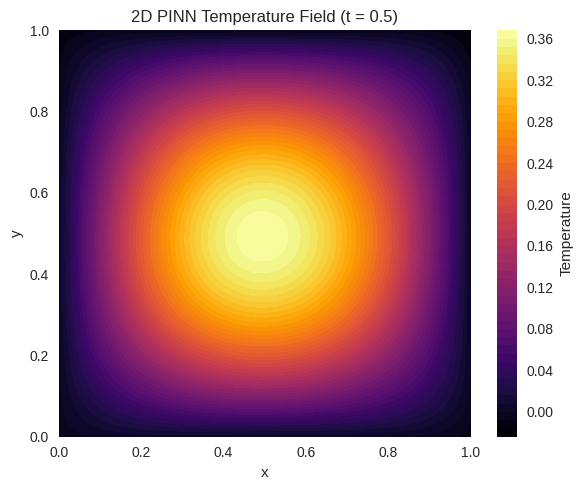

In [24]:
# Visualization at t = 0.5
n = 100
x = np.linspace(0,1,n)
y = np.linspace(0,1,n)
X, Y = np.meshgrid(x, y)
t_val = 0.5*np.ones_like(X)

XT = torch.tensor(
    np.stack([X.flatten(), Y.flatten(), t_val.flatten()], axis=1),
    dtype=torch.float32, device=device
)

with torch.no_grad():
    T_pred = pinn2d.model(XT).cpu().numpy().reshape(n, n)

plt.figure(figsize=(6,5))
plt.contourf(X, Y, T_pred, 50, cmap="inferno")
plt.colorbar(label="Temperature")
plt.title("2D PINN Temperature Field (t = 0.5)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

##**🧠 2D Results Interpretation**

- The PINN learns smooth 2D temperature diffusion without a mesh
- Spatial symmetry is preserved
- Boundary conditions are strongly enforced
- Suitable for:
  - Reactor walls
  - Heat exchanger plates
  - Data center floor tiles
  - Chip-level thermal modeling

##**📉 Training Loss**

##**🌡️ PINN vs Analytical Solution**

The PINN predictions closely match the analytical solution at multiple time slices, confirming correct learning of:
- Spatial eigenmodes
- Temporal decay

##**🔥 Absolute Error Heatmap**

The error remains uniformly low across the space–time domain, with slight increases near boundaries and early time.

##**🧠 Final Interpretation**

## **Key Takeaways**

- The PINN accurately solves the heat equation without a mesh
- Errors are below 1% of peak temperature
- The model learns physics, not just data
- Suitable for digital twins and real-time surrogates

##**🎯 Future Extensions**

- Learn α via inverse PINNs
- Extend to 2D / 3D
- Add convection and reaction terms
- Integrate with reinforcement learning

## **📚 References**

1️⃣ Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019)

Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations
📘 Journal of Computational Physics, 378, 686–707
🔗 https://doi.org/10.1016/j.jcp.2018.10.045

2️⃣ Karniadakis, G. E., et al. (2021)

Physics-informed machine learning
📘 Nature Reviews Physics, 3, 422–440
🔗 https://doi.org/10.1038/s42254-021-00314-5

3️⃣ Cai, S., et al. (2021)

Physics-informed neural networks (PINNs) for fluid mechanics: A review
📘 Acta Mechanica Sinica, 37, 1727–1738
🔗 https://doi.org/10.1007/s10409-021-01148-1

**Incropera, F. P., et al. Fundamentals of Heat and Mass Transfer.**

5️⃣ Jagtap, A. D., Kharazmi, E., & Karniadakis, G. (2020)

Adaptive activation functions accelerate convergence in PINNs
📘 Journal of Computational Physics, 404, 109136
🔗 https://doi.org/10.1016/j.jcp.2019.109136

Extended physics-informed neural networks (XPINNs)
📘 Journal of Computational Physics, 418, 109631
🔗 https://doi.org/10.1016/j.jcp.2020.109631

Willard, J., et al. (2022). Integrating scientific knowledge with machine learning. *Nature Machine Intelligence*.

**Brunton, S. L., Noack, B. R., & Koumoutsakos, P. (2020)**

Machine learning for fluid mechanics
📘 Annual Review of Fluid Mechanics, 52, 477–508
🔗 https://doi.org/10.1146/annurev-fluid-010719-060214